# Tech Challenge Fase 3 — a análise que decidiu o projeto

Este notebook percorre os achados que mudaram o rumo do projeto, na ordem em
que aconteceram. Ele **não é a pipeline** — essa vive em `src/` e é executada
pelos scripts. Aqui o objetivo é mostrar *como sabemos o que sabemos*.

O projeto entrega duas coisas, e a segunda só existe por causa da primeira:

1. **Modelo aluno-nível** — executado com rigor e **reprovado** no próprio
   critério de falsificação.
2. **Priorização municipal intra-UF** — o que sobrou de pé depois de testar
   tudo, mais uma advertência de validade que atinge a Fase 2.

> Para regenerar este notebook do zero:
> `python src/visualization/02_gerar_notebook.py`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FASE2 = BASE.parent / "tech-challenge-fase2-alfabetizacao"
REPORTS = BASE / "reports"
IMAGES = BASE / "images"
IMAGES.mkdir(exist_ok=True)

# Sistema de cor do projeto, ajustado para marca de dado (ver docstring do gerador)
TEAL, AMBAR, TERRACOTA = "#0F9086", "#A9661F", "#B4553C"
INK, MUTED, GRID = "#16211F", "#67746F", "#D8DEDB"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130,
    "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def carregar(nome):
    return json.loads((REPORTS / nome).read_text(encoding="utf-8"))

print("Relatórios disponíveis:")
for p in sorted(REPORTS.glob("*.json")):
    print(" ", p.name)

Relatórios disponíveis:
  experimento_opcaoB_municipio.json
  guarda_leakage.json
  metrics_baseline.json
  metrics_tournament.json
  ranking_intra_uf.json
  shap_interpretabilidade.json
  teste_falsificacao.json
  teste_residuo.json


## 1. O vazamento que sustentava o resultado

O projeto encontrou **cinco colunas** que codificavam o mesmo evento — *o aluno
faltou à prova* —, e quem falta recebe rótulo "não alfabetizado" por convenção
do indicador, não por medição.

Três vazavam pelo **valor** (`proficiencia`, `presenca`,
`preenchimento_caderno`). A quarta (`peso_aluno`) vazava pela **nulidade**. A
quinta é a mais instrutiva: `caderno=12` parecia uma categoria de altíssimo
risco (87,3% de "Não"), e três buscas na documentação oficial do INEP não
explicaram por quê.

Um `crosstab` de duas colunas resolveu em segundos o que a documentação não
resolveu.

In [2]:
alunos = pd.read_csv(FASE2 / "dados" / "Alunos.csv",
                     usecols=["caderno", "presenca", "alfabetizado"])

tab = alunos.groupby("caderno").apply(lambda g: pd.Series({
    "n": len(g),
    "% ausente": (g.presenca == "Ausente").mean() * 100,
    '% "Não" (todos)': (g.alfabetizado == "Não").mean() * 100,
    '% "Não" (só presentes)': (g.loc[g.presenca != "Ausente", "alfabetizado"] == "Não").mean() * 100,
}), include_groups=False).round(1)

print(tab.to_string())
print()
print('O caderno 12 tem 79,7% de ausentes contra 12-16% dos outros.')
print('Entre quem FEZ a prova, esses alunos vão MELHOR que a média (37,3% vs ~41%).')
print('Os 87,3% eram artefato de ausência — não característica do aluno.')

               n  % ausente  % "Não" (todos)  % "Não" (só presentes)
caderno                                                             
1        22831.0       15.7             50.6                    41.4
10       16246.0       12.8             48.4                    40.9
11       16154.0       12.6             48.8                    41.4
12        2551.0       79.7             87.3                    37.3

O caderno 12 tem 79,7% de ausentes contra 12-16% dos outros.
Entre quem FEZ a prova, esses alunos vão MELHOR que a média (37,3% vs ~41%).
Os 87,3% eram artefato de ausência — não característica do aluno.


## 2. O teste de falsificação — o critério que o projeto escreveu para si

O `ADR-0001 §5` definiu, antes de qualquer treino, o que reprovaria o projeto:
o modelo aluno-nível precisa **superar** o baseline trivial de aplicar um
número do município igualmente a todos os seus alunos.

Esse critério ficou escrito e **nunca executado** até uma auditoria interna
notar. Quando rodou, passou — e aí descobrimos que a régua estava baixa: o
baseline usado (taxa bruta t-1) era mais fraco que o disponível (a meta do
PDE). Corrigido o baseline, o veredito inverteu.

In [3]:
f = carregar("teste_falsificacao.json")
pres = f["so_presentes"]

print("População que importa: só quem fez a prova (rótulo = medição real)")
print(f"  n de teste: {pres['n_teste']:,}".replace(",", "."))
print()
for nome, auc in pres["roc_auc"].items():
    print(f"  {nome:<28} ROC-AUC {auc:.4f}")

ic = pres["ic_diferenca"]
print()
print(f"  Diferença modelo − baseline: {ic['diferenca_observada']:+.4f}")
print(f"  IC95% bootstrap pareado:     [{ic['ic95_inferior']:+.4f}, {ic['ic95_superior']:+.4f}]")
print()
print(f"  VEREDITO: {f['veredito']}")

População que importa: só quem fez a prova (rótulo = medição real)
  n de teste: 24.505

  modelo_aluno                 ROC-AUC 0.6013
  baseline_taxa_nao_alfab_t1   ROC-AUC 0.5816
  baseline_meta_pde            ROC-AUC 0.6331
  baseline_combinado_ranks     ROC-AUC 0.6214
  baseline_municipal           ROC-AUC 0.6331

  Diferença modelo − baseline: -0.0318
  IC95% bootstrap pareado:     [-0.0374, -0.0261]

  VEREDITO: FALHOU


## 3. O teste de resíduo — sobra sinal individual?

A comparação acima trata modelo e baseline como alternativas concorrentes. Mas
o modelo **já tinha** a meta municipal entre as features — então ela não isola
a pergunta certa: *dado que vou usar o baseline municipal de qualquer forma,
adicionar informação de aluno melhora alguma coisa?*

O método correto é dar o baseline ao modelo **como feature** e medir o
incremento.

In [4]:
r = carregar("teste_residuo.json")

print(f"  Modelo A (só o baseline municipal):        AUC {r['roc_auc']['modelo_a_so_baseline']:.4f}")
print(f"  Modelo B (baseline + features de aluno):   AUC {r['roc_auc']['modelo_b_baseline_mais_features']:.4f}")
ic = r["ic_diferenca_b_menos_a"]
print()
print(f"  Diferença (B − A): {ic['diferenca_observada']:+.4f}   "
      f"IC95% [{ic['ic95_inferior']:+.4f}, {ic['ic95_superior']:+.4f}]")
print()
print(f"  {r['veredito']}")
print()
print("  Adicionar features de aluno ao baseline PIORA o resultado,")
print("  com significância estatística. O resíduo é vazio.")

  Modelo A (só o baseline municipal):        AUC 0.6331
  Modelo B (baseline + features de aluno):   AUC 0.6013

  Diferença (B − A): -0.0318   IC95% [-0.0374, -0.0261]

  SEM RESIDUO — modelo B PERDE do baseline sozinho, com significancia

  Adicionar features de aluno ao baseline PIORA o resultado,
  com significância estatística. O resíduo é vazio.


## 4. A reformulação — e se o problema for o alvo, não o algoritmo?

Com o resíduo vazio, a pergunta mudou: no grão em que o dado **nasce**
(município), dá para prever quem não atinge a meta do PDE?

O experimento tem 5 etapas e **a ordem é o argumento**: as três primeiras
produzem um resultado que parece vitória; a quarta mostra que ela dependia de
informação contemporânea do estado.

In [5]:
e = carregar("experimento_opcaoB_municipio.json")

print(f"N = {e['n_municipios']:,} municípios | taxa base de risco: {e['taxa_risco_base']:.1%}"
      .replace(",", "."))
print()
print("ABLAÇÃO — de onde vem o poder preditivo?")
for k, v in e["etapa2_ablacao"].items():
    marca = "  <<< salto de +0,21" if "UF" in k and "contexto" not in k else ""
    print(f"  {k:<26} AUC {v:.4f}{marca}")

print()
print("O SALTO É A UF. E o k-fold aleatório deixa municípios do mesmo estado")
print("no treino E no teste — o modelo aprende a taxa do estado olhando")
print("vizinhos do MESMO ano, informação que uma previsão real não teria.")
print()
print("=" * 62)
print(f"  k-fold aleatório (parece vitória):  AUC {e['etapa3_falsificacao']['auc_modelo']:.4f}")
print(f"  lookup de UF (baseline):            AUC {e['etapa3_falsificacao']['auc_lookup_uf']:.4f}")
print(f"  LEAVE-ONE-UF-OUT (teste honesto):   AUC {e['etapa4_leave_one_uf_out']['auc_leave_one_uf_out']:.4f}")
print("=" * 62)
print("  Colapso: abaixo do acaso (0,500). O 'sinal' era a régua estadual.")

N = 5.232 municípios | taxa base de risco: 46.7%

ABLAÇÃO — de onde vem o poder preditivo?
  só taxa23                  AUC 0.5507
  só meta2024                AUC 0.5304
  taxa23 + meta2024          AUC 0.5521
  taxa23 + meta2024 + UF     AUC 0.7663  <<< salto de +0,21
  só contexto (pop + UF)     AUC 0.7362
  TUDO                       AUC 0.7709

O SALTO É A UF. E o k-fold aleatório deixa municípios do mesmo estado
no treino E no teste — o modelo aprende a taxa do estado olhando
vizinhos do MESMO ano, informação que uma previsão real não teria.

  k-fold aleatório (parece vitória):  AUC 0.7709
  lookup de UF (baseline):            AUC 0.7294
  LEAVE-ONE-UF-OUT (teste honesto):   AUC 0.4800
  Colapso: abaixo do acaso (0,500). O 'sinal' era a régua estadual.


## 5. Por que a UF domina: cada estado aplica sua própria prova

As avaliações do Compromisso Nacional Criança Alfabetizada são aplicadas
**pelos estados**. Isso significa que a comparação entre UFs não mede só
política educacional — mede também diferença de régua.

O gráfico abaixo mostra a variação da taxa de alfabetização entre 2023 e 2024
por estado. Uma queda de 20 pontos percentuais em um ano não é perda de
aprendizado real.

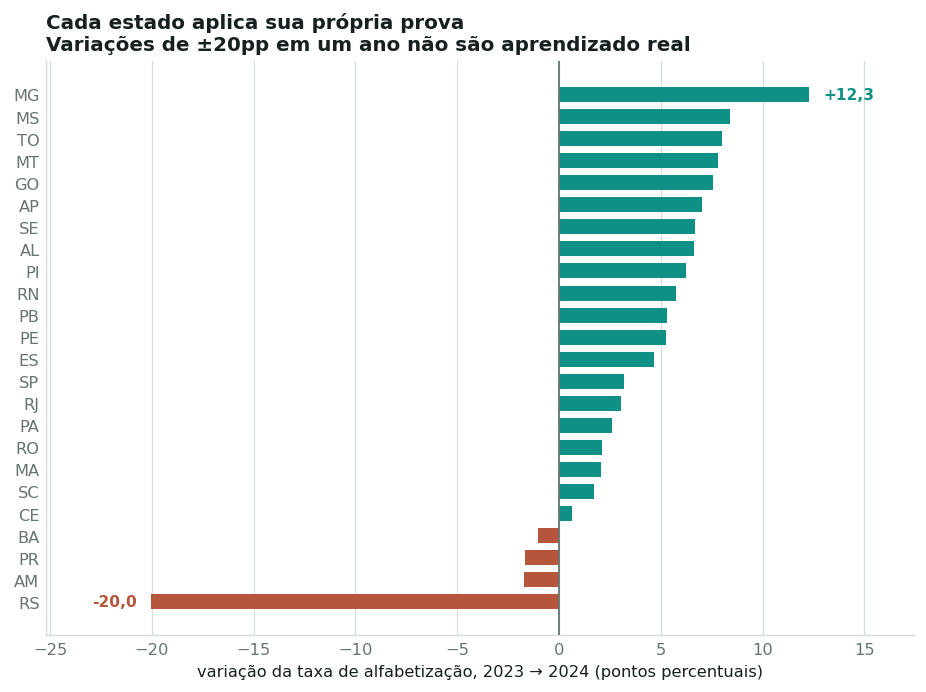

corr(variação da UF, taxa de falha) = -0.651
corr(nível de 2023,  taxa de falha) = -0.431

A correlação com a VARIAÇÃO é mais forte que com o NÍVEL —
não é artefato mecânico da fórmula da meta, é o choque do ano.


In [6]:
metas = pd.read_csv(FASE2 / "dados" / "br_inep_avaliacao_alfabetizacao_meta_alfabetizacao_municipio.csv.gz")
metas["id_municipio"] = metas["id_municipio"].astype(str).str.zfill(7)

d23 = metas[metas.ano == 2023][["id_municipio", "taxa_alfabetizacao", "meta_alfabetizacao_2024"]] \
    .rename(columns={"taxa_alfabetizacao": "t23"})
d24 = metas[metas.ano == 2024][["id_municipio", "taxa_alfabetizacao"]] \
    .rename(columns={"taxa_alfabetizacao": "t24"})
m = d23.merge(d24, on="id_municipio").dropna(subset=["t23", "t24", "meta_alfabetizacao_2024"])
m["uf_pref"] = m.id_municipio.str[:2]
m["falhou"] = (m.t24 < m.meta_alfabetizacao_2024).astype(int)
m["delta"] = m.t24 - m.t23

UF = {"11":"RO","12":"AC","13":"AM","14":"RR","15":"PA","16":"AP","17":"TO","21":"MA",
      "22":"PI","23":"CE","24":"RN","25":"PB","26":"PE","27":"AL","28":"SE","29":"BA",
      "31":"MG","32":"ES","33":"RJ","35":"SP","41":"PR","42":"SC","43":"RS","50":"MS",
      "51":"MT","52":"GO","53":"DF"}
g = m.groupby("uf_pref").agg(n=("falhou","size"), delta=("delta","mean"),
                              falha=("falhou","mean")).reset_index()
g["uf"] = g.uf_pref.map(UF)
g = g.sort_values("delta")

fig, ax = plt.subplots(figsize=(7.2, 5.4))
cores = [TERRACOTA if d < 0 else TEAL for d in g.delta]
ax.barh(g.uf, g.delta, color=cores, height=0.68, zorder=3)
ax.axvline(0, color=MUTED, lw=1, zorder=4)
ax.grid(axis="x", color=GRID, lw=0.7, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel("variação da taxa de alfabetização, 2023 → 2024 (pontos percentuais)")
ax.set_title("Cada estado aplica sua própria prova\n"
             "Variações de ±20pp em um ano não são aprendizado real",
             loc="left", fontweight="bold", color=INK)

# folga nos dois lados para os rótulos diretos caberem sem colidir
span = g.delta.max() - g.delta.min()
ax.set_xlim(g.delta.min() - span * 0.16, g.delta.max() + span * 0.16)

# rótulo direto só nos extremos — nunca um número em cada barra
for uf, d in [(g.iloc[0].uf, g.iloc[0].delta), (g.iloc[-1].uf, g.iloc[-1].delta)]:
    ax.text(d + (-0.7 if d < 0 else 0.7), uf, f"{d:+.1f}".replace(".", ","),
            va="center", ha="right" if d < 0 else "left",
            fontsize=8.5, fontweight="bold", color=TERRACOTA if d < 0 else TEAL)

ax.tick_params(length=0)
fig.tight_layout()
fig.savefig(IMAGES / "efeito_regua_estadual.png", bbox_inches="tight", facecolor="white")
plt.show()

print(f"corr(variação da UF, taxa de falha) = {g.delta.corr(g.falha):+.3f}")
print(f"corr(nível de 2023,  taxa de falha) = {g.set_index('uf').join(m.groupby('uf_pref').t23.mean().rename(index=UF)).t23.corr(g.set_index('uf').falha):+.3f}")
print()
print("A correlação com a VARIAÇÃO é mais forte que com o NÍVEL —")
print("não é artefato mecânico da fórmula da meta, é o choque do ano.")

### A consequência: nosso próprio ranking nacional é inválido

Os marts `agg_municipio_ranking` e `agg_priorizacao` — da **nossa Fase 2, em
produção** — ordenam municípios **nacionalmente** por taxa de alfabetização e
gap até a meta.

Se cada estado aplica sua própria prova e a variação estadual chega a ±20pp em
um ano, comparar um município do RS com um de MG nessa escala **não é
comparação válida**. Um gestor lendo esse ranking direcionaria recursos para
municípios gaúchos ("90% falharam a meta") quando parte substancial do efeito
é a régua do estado, não a política municipal.

Isso não invalida a engenharia daqueles marts — invalida a *leitura nacional*
que se faz em cima deles.

## 6. O que funciona: priorização dentro do estado

Controlada a régua estadual, características municipais **preveem** quem fica
para trás. E o baseline intuitivo — *"priorize quem estava pior em 2023"* — é
**ativamente errado**: fica abaixo do sorteio aleatório.

O motivo é regressão à média somada à meta progressiva do PDE: municípios com
taxa baixa em 2023 tendem a melhorar mais e a bater a meta com mais
frequência.

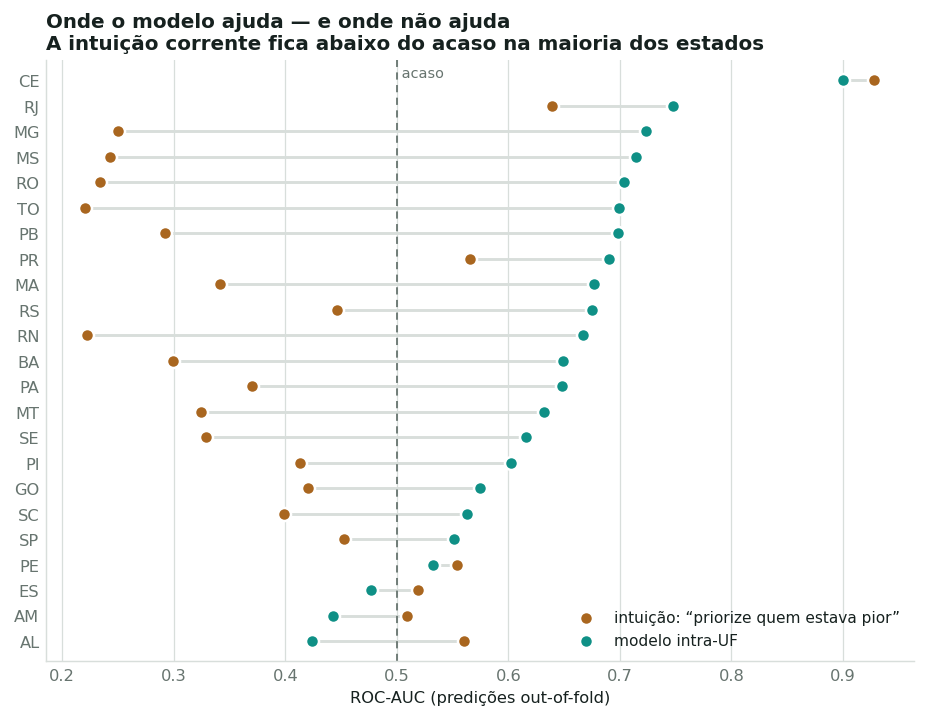

  AUC do modelo (média ponderada):  0.6478
  AUC da intuição corrente:         0.4032  (abaixo do acaso)
  UFs em que o modelo vence:        18 de 23
  Municípios pontuados:             5.216

  Os estados em que o modelo perde (AL, AM, CE, ES, PE) aparecem no painel
  com alerta explícito — não escondidos atrás da média nacional. Em
  estados pequenos (validação adaptativa, ADR-0004) o IC95% costuma
  ser largo o bastante pra 'perde' ser inconclusivo, não uma derrota clara.


In [7]:
rk = carregar("ranking_intra_uf.json")
met = pd.DataFrame(rk["metricas_por_uf"]).sort_values("auc_modelo")

fig, ax = plt.subplots(figsize=(7.2, 5.6))
y = np.arange(len(met))

# haste ligando os dois valores — o que importa é a DISTÂNCIA entre eles
for yi, (a, b) in enumerate(zip(met.auc_baseline_intuicao, met.auc_modelo)):
    ax.plot([a, b], [yi, yi], color=GRID, lw=1.6, zorder=1, solid_capstyle="round")

ax.scatter(met.auc_baseline_intuicao, y, s=52, color=AMBAR, zorder=3,
           label="intuição: “priorize quem estava pior”", edgecolor="white", linewidth=1.4)
ax.scatter(met.auc_modelo, y, s=52, color=TEAL, zorder=3,
           label="modelo intra-UF", edgecolor="white", linewidth=1.4)

ax.axvline(0.5, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
ax.set_ylim(-0.8, len(met) - 0.2)   # folga no topo para o rótulo do acaso
ax.text(0.5, len(met) - 0.45, " acaso", fontsize=8, color=MUTED, va="top")

ax.set_yticks(y, met.uf)
ax.set_xlabel("ROC-AUC (predições out-of-fold)")
ax.set_title("Onde o modelo ajuda — e onde não ajuda\n"
             "A intuição corrente fica abaixo do acaso na maioria dos estados",
             loc="left", fontweight="bold", color=INK)
ax.grid(axis="x", color=GRID, lw=0.7, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
fig.tight_layout()
fig.savefig(IMAGES / "modelo_vs_intuicao_por_uf.png", bbox_inches="tight", facecolor="white")
plt.show()

res = rk["resumo"]
print(f"  AUC do modelo (média ponderada):  {res['auc_modelo_ponderado']:.4f}")
print(f"  AUC da intuição corrente:         {res['auc_intuicao_ponderado']:.4f}  (abaixo do acaso)")
print(f"  UFs em que o modelo vence:        {res['ufs_modelo_vence']} de {res['ufs']}")
print(f"  Municípios pontuados:             {res['municipios']:,}".replace(",", "."))
print()
perdedores = ", ".join(m["uf"] for m in rk["metricas_por_uf"] if not m["modelo_vence"])
print(f"  Os estados em que o modelo perde ({perdedores}) aparecem no painel")
print("  com alerta explícito — não escondidos atrás da média nacional. Em")
print("  estados pequenos (validação adaptativa, ADR-0004) o IC95% costuma")
print("  ser largo o bastante pra 'perde' ser inconclusivo, não uma derrota clara.")

## 7. O que sai disso

**Duas recomendações de política pública, ambas com intervalo de confiança:**

1. **Busca ativa de alunos** → usar a **meta do PDE do município**, não um
   modelo aluno-nível. Mais simples, mais barata, e estatisticamente mais
   eficaz com os dados disponíveis.
2. **Priorização entre municípios** → comparar **dentro do estado**, nunca
   entre estados, usando o modelo intra-UF — porque a intuição corrente tem
   desempenho abaixo do acaso.

A recomendação 2 não fica em prosa: `reports/painel_intra_uf.html` é a
ferramenta, com 5.216 municípios e a advertência de validade embutida na
interface — o painel **não tem visão nacional, de propósito**.

---

### O que este projeto demonstra

Definir um critério de falsificação antes de medir, executá-lo, **desconfiar da
própria vitória quando ela aparece**, corrigir a régua e reportar o resultado
desfavorável com significância — duas vezes, em dois grãos diferentes.

O resultado negativo do modelo aluno-nível não é o fracasso do projeto. É o
que dá credibilidade ao resultado positivo do modelo intra-UF.